# Librerias

In [1]:
import pandas as pd
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Carga de la bbdd y reducción

## 1. Cargar csv

In [2]:
#cargar datos
df = pd.read_parquet("../data/df_limpiado_260427.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para segmentar
cols = ["age", "job", "marital", "education", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.head()

,age,job,marital,education,housing,loan,deposit
0,59,administration,married,secondary,yes,no,yes
1,56,administration,married,secondary,no,no,yes
2,41,technician,married,secondary,yes,no,yes
3,55,services,married,secondary,yes,no,yes
4,54,administration,married,tertiary,no,no,yes


## 2. Categorizar edad

In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

## 3. Convertir todas a categóricas

In [5]:
for col in df_perfil.columns:
    df_perfil[col] = df_perfil[col].astype(str)

In [6]:
df_perfil = df_perfil.reset_index(drop=True)
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 10987 entries, 0 to 10986
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   job        10987 non-null  str  
 1   marital    10987 non-null  str  
 2   education  10987 non-null  str  
 3   housing    10987 non-null  str  
 4   loan       10987 non-null  str  
 5   deposit    10987 non-null  str  
 6   age_group  10987 non-null  str  
dtypes: str(7)
memory usage: 1002.1 KB


# Perfil del cliente

## 1. Preparar datos para K‑Modes

In [7]:
cols_modelo = ["age_group", "job", "marital", "education"]

df_perfil_m = df_perfil[cols_modelo].copy()
df_perfil_m.head()

,age_group,job,marital,education
0,56-65,administration,married,secondary
1,56-65,administration,married,secondary
2,36-45,technician,married,secondary
3,46-55,services,married,secondary
4,46-55,administration,married,tertiary


In [8]:
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

## 2. Método del codo para elegir k

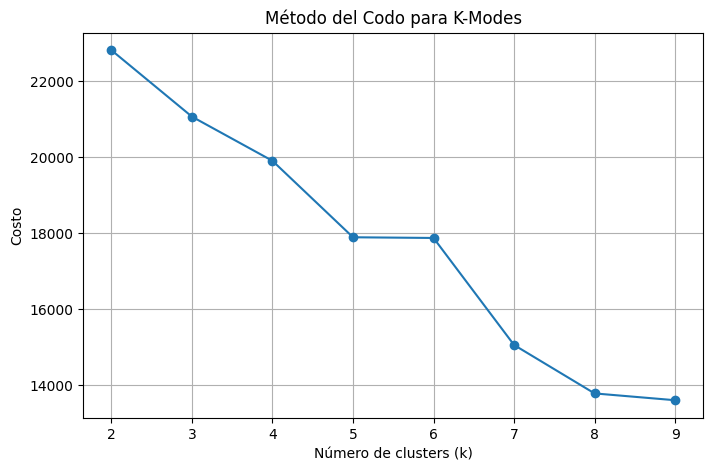

In [9]:
costs = []
ks = range(2, 10)

for k in ks:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    clusters = km.fit_predict(X)
    costs.append(km.cost_)

# Graficar la curva del codo, el “codo” es donde la curva deja de bajar bruscamente, ese será k óptimo
plt.figure(figsize=(8,5))
plt.plot(ks, costs, marker='o')
plt.title("Método del Codo para K-Modes")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

## 3. Entrenar K‑Modes

In [10]:
k_opt = 5

km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

In [11]:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5546
1    1758
2    1212
3    1005
4    1466
Name: count, dtype: int64

In [12]:
df_perfil.head()

,job,marital,education,housing,loan,deposit,age_group,cluster
0,administration,married,secondary,yes,no,yes,56-65,0
1,administration,married,secondary,no,no,yes,56-65,0
2,technician,married,secondary,yes,no,yes,36-45,0
3,services,married,secondary,yes,no,yes,46-55,0
4,administration,married,tertiary,no,no,yes,46-55,2


## 3. Ver los centroides de cada cluster

In [13]:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

## 4. Perfil de productos por cluster

In [ ]:
perfil_clusters = pd.DataFrame(km.cluster_centroids_, columns=cols_modelo)

perfil_clusters.index = [f"Cluster {i}" for i in range(perfil_clusters.shape[0])]

perfil_clusters

,age_group,job,marital,education
Cluster 0,26-35,management,married,secondary
Cluster 1,36-45,technician,single,tertiary
Cluster 2,46-55,technician,married,tertiary
Cluster 3,46-55,administration,single,secondary
Cluster 4,36-45,blue-collar,married,primary


## 5. Perfil demográfico por cluster

In [15]:
#Distribución de age_group:
cluster_age = pd.crosstab(df_perfil["cluster"], df_perfil["age_group"], normalize="index")
cluster_age

age_group,26-35,36-45,46-55,56-65,65+,<=25
cluster,,,,,,
0,0.529030,0.227010,0.088172,0.118824,0.030112,0.006852
1,0.262799,0.556314,0.042662,0.031286,0.007964,0.098976
2,0.065182,0.000000,0.806106,0.082508,0.041254,0.004950
3,0.208955,0.151244,0.381095,0.039801,0.002985,0.215920
4,0.110505,0.490450,0.129604,0.150750,0.111869,0.006821


In [16]:
#Distribución de job:
cluster_job = pd.crosstab(df_perfil["cluster"], df_perfil["job"], normalize="index")
cluster_job

job,administration,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,0.091237,0.129463,0.026145,0.016048,0.330148,0.062027,0.031374,0.118103,0.018211,0.137036,0.034800,0.005409
1,0.065984,0.051763,0.047213,0.017634,0.183732,0.024460,0.083618,0.055176,0.080774,0.333333,0.050057,0.006257
2,0.023927,0.024752,0.046205,0.054455,0.287954,0.103135,0.043729,0.037954,0.000825,0.344884,0.016502,0.015677
3,0.636816,0.077612,0.011940,0.012935,0.008955,0.013930,0.011940,0.065672,0.112438,0.019900,0.025871,0.001990
4,0.018417,0.673943,0.016371,0.046385,0.015689,0.166439,0.008186,0.028649,0.001364,0.006139,0.012960,0.005457


In [17]:
#Distribución de marital:
cluster_marital = pd.crosstab(df_perfil["cluster"], df_perfil["marital"], normalize="index")
cluster_marital

marital,divorced,married,single
cluster,,,
0,0.077894,0.672016,0.250090
1,0.134243,0.111490,0.754266
2,0.161716,0.838284,0.000000
3,0.207960,0.125373,0.666667
4,0.136426,0.802183,0.061392


In [18]:
#Distribución de education:
cluster_edu = pd.crosstab(df_perfil["cluster"], df_perfil["education"], normalize="index")
cluster_edu

education,primary,secondary,tertiary,unknown
cluster,,,,
0,0.019293,0.649297,0.292463,0.038947
1,0.032992,0.187144,0.719568,0.060296
2,0.131188,0.182343,0.614686,0.071782
3,0.024876,0.950249,0.005970,0.018905
4,0.763302,0.194407,0.002046,0.040246


In [19]:
#Propensión deposit:
cluster_deposit = pd.crosstab(df_perfil["cluster"], df_perfil["deposit"], normalize="index")
cluster_deposit

deposit,no,yes
cluster,,
0,0.526686,0.473314
1,0.432878,0.567122
2,0.535479,0.464521
3,0.462687,0.537313
4,0.615280,0.384720


In [20]:
#Propensión loan:
cluster_loan = pd.crosstab(df_perfil["cluster"], df_perfil["loan"], normalize="index")
cluster_loan

loan,no,yes
cluster,,
0,0.867292,0.132708
1,0.912969,0.087031
2,0.863861,0.136139
3,0.833831,0.166169
4,0.856753,0.143247


In [21]:
#Propensión housing:
cluster_housing = pd.crosstab(df_perfil["cluster"], df_perfil["housing"], normalize="index")
cluster_housing

housing,no,yes
cluster,,
0,0.512261,0.487739
1,0.582480,0.417520
2,0.638614,0.361386
3,0.528358,0.471642
4,0.432469,0.567531


In [ ]:
#Resumen propensión productos:
propension_productos = (df_perfil.groupby("cluster")[["deposit", "loan", "housing"]].apply(lambda x: (x == "yes").mean()))

propension_productos

,deposit,loan,housing
cluster,,,
0,0.473314,0.132708,0.487739
1,0.567122,0.087031,0.417520
2,0.464521,0.136139,0.361386
3,0.537313,0.166169,0.471642
4,0.384720,0.143247,0.567531


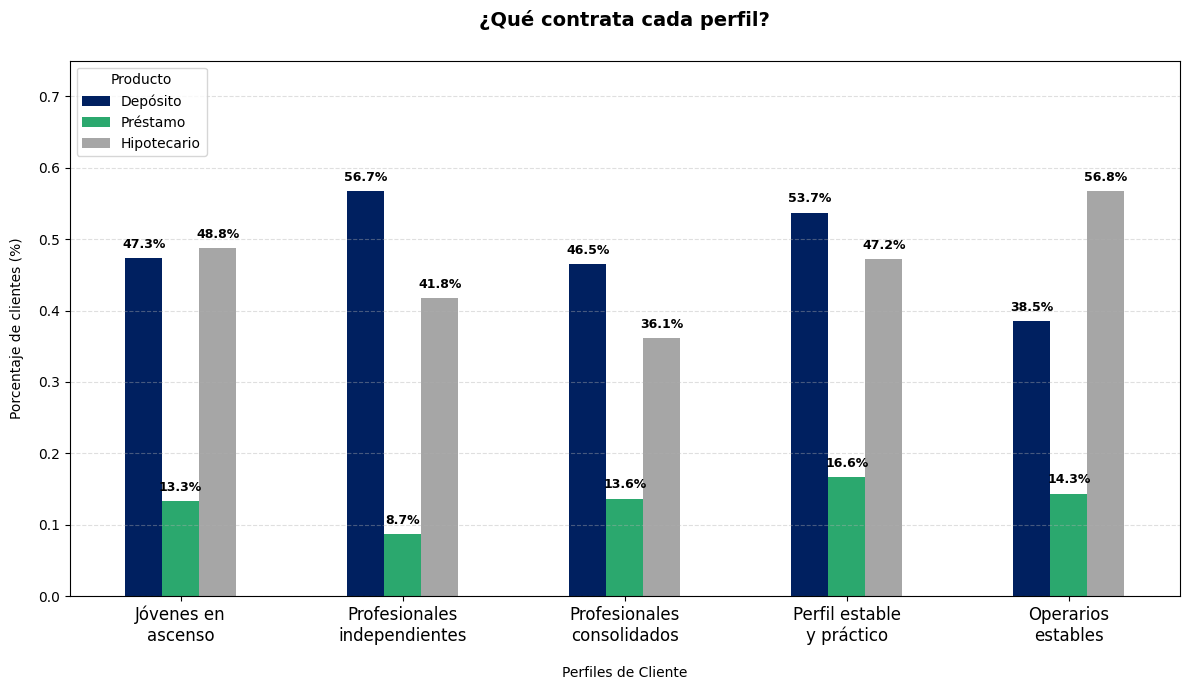

In [28]:
# 1. Nombres con salto de línea para que queden en dos filas
nombres_clusters = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

# 2. Creamos el gráfico
ax = propension_productos.plot(kind='bar', figsize=(12, 7), color=['#002060', "#2BA86E", '#A6A6A6'])

# 3. Títulos y etiquetas
plt.title("¿Qué contrata cada perfil?", fontsize=14, fontweight='bold', pad=25)
plt.ylabel("Porcentaje de clientes (%)", labelpad=10)
plt.xlabel("Perfiles de Cliente", labelpad=15)

# Ajuste de nombres en el eje X
plt.xticks(range(len(nombres_clusters)), nombres_clusters, rotation=0, fontsize=12)

# --- CAMBIO CLAVE: UBICACIÓN DE LA LEYENDA ---
# 'upper left' la mueve a la izquierda, y aumentamos el límite de Y para dar espacio
plt.legend(title="Producto", labels=['Depósito', 'Préstamo', 'Hipotecario'], loc='upper left')
plt.ylim(0, 0.75) # Aumentamos el tope al 75% para que la leyenda no tape las barras
# ---------------------------------------------

plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Etiquetas de porcentaje sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points', 
                fontsize=9, 
                fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Indicador para valorar para poder comparar clusters:
Índice de propensión

In [ ]:
#Probabilidad global:
p_global = {"deposit": (df_perfil["deposit"] == "yes").mean(),
            "loan": (df_perfil["loan"] == "yes").mean(),
            "housing": (df_perfil["housing"] == "yes").mean()}

#Probabilidad por cluster:
p_cluster = df_perfil.groupby("cluster")[["deposit", "loan", "housing"]].apply(lambda x: (x == "yes").mean())

#Índice de propensión:
indice_propension = pd.DataFrame({"deposit_index": p_cluster["deposit"] / p_global["deposit"],
                                  "loan_index": p_cluster["loan"] / p_global["loan"],
                                  "housing_index": p_cluster["housing"] / p_global["housing"]})

indice_propension

,deposit_index,loan_index,housing_index
cluster,,,
0,0.983230,1.018914,1.033916
1,1.178099,0.668209,0.885065
2,0.964964,1.045252,0.766072
3,1.116177,1.275821,0.999793
4,0.799191,1.099828,1.203060


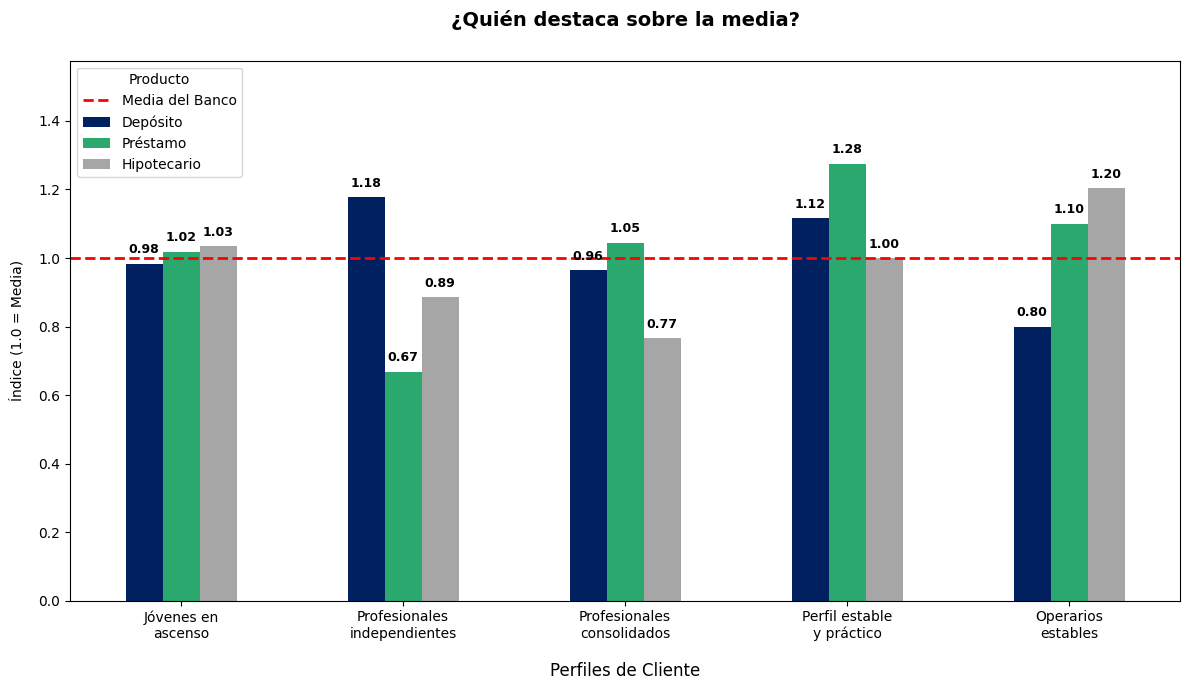

In [30]:
#Nombres con salto de línea para legibilidad
nombres_clusters = [
    "Jóvenes en\nascenso", 
    "Profesionales\nindependientes", 
    "Profesionales\nconsolidados", 
    "Perfil estable\ny práctico", 
    "Operarios\nestables"
]

#columnas  castellano
indice_es = indice_propension.rename(columns={
    "deposit_index": "Depósito",
    "loan_index": "Préstamo",
    "housing_index": "Hipotecario"
})
ax = indice_es.plot(kind='bar', figsize=(12, 7), color=['#002060', "#2BA86E", '#A6A6A6'])

#Título y Etiquetas
plt.title("¿Quién destaca sobre la media?", fontsize=14, fontweight='bold', pad=25)
plt.ylabel("Índice (1.0 = Media)", labelpad=10)
plt.xlabel("Perfiles de Cliente", fontsize=12, labelpad=15) # 

plt.xticks(range(len(nombres_clusters)), nombres_clusters, rotation=0, fontsize=10)

#Línea de referencia 
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label="Media del Banco")

#Leyenda
plt.legend(title="Producto", loc='upper left')
plt.ylim(0, max(indice_es.max()) + 0.3) # Espacio para que no tape nada

#Etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points', 
                fontsize=9, 
                fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Conclusiones

PENDIENTE

**Cluster 0 — Jóvenes profesionales**

- Demografía:
    - Edad: 53% entre 26–35
    - Trabajo: 32% management
    - Estado civil: 67% married
    - Educación: 65% secundaria

- Productos:
    - Deposit: 48.8% / índice = 0.98
    - Loan: 13.1% sí / índice = 1.01
    - Housing: 48.4% sí / índice = 1.03

⭐Interpretación:

Clientes jóvenes, con estabilidad laboral y familiar, en fase de crecimiento económico. No destaca especialmente en ningún producto, pero tiene una ligera tendencia a contratar **hipotecas**.

⭐Oportunidades:

Hipoteca joven / Planes de ahorro sistemático / Tarjetas crédito premium para familias jóvenes

**Cluster 1 — Profesionales técnicos, solteros y muy formados**

- Demografía:
    - Edad: 55% entre 36–45
    - Trabajo: 33% technician
    - Estado civil: 75% single
    - Educación: 72% terciaria

- Productos:
    - Deposit: 58.3% / índice = 1.17 EL MÁS ALTO
    - Loan: 8.7% / índice = 0.67 MUY POR DEBAJO MEDIA
    - Housing: 41.5% / índice = 0.88

⭐Interpretación:

Clientes con alta capacidad de ahorro, independientes, con ingresos estables y sin cargas familiares. Es el más propenso a contratar depósitos, no demanda crédito ni hipoteca.

⭐Oportunidades:

Cuentas remuneradas

**Cluster 2 — Profesionales senior, casados y muy estables**

- Demografía:
    - Edad: 80% entre 46–55
    - Trabajo: 35% technician, 28% management
    - Estado civil: 84% married
    - Educación: 61% terciaria

- Productos:
    - Deposit: 48.0% / índice = 0.96
    - Loan: 13.5% / índice = 1.04
    - Housing: 36.1% / índice = 0.77 POR DEBAJO MEDIA

⭐Interpretación:

Clientes con alta estabilidad económica, ingresos altos y etapa de consolidación patrimonial. Estable, con ligera propensión a **préstamos** personales, pero baja propensión a hipoteca (ya la tienen).

⭐Oportunidades:

Planes de pensiones / Gestión patrimonial

**Cluster 3 — Administrativos solteros de mediana edad**

- Demografía:
    - Edad: 37% entre 46–55
    - Trabajo: 64% administración
    - Estado civil: 66% single
    - Educación: 95% secundaria

- Productos:
    - Deposit: 55.3% / índice = 1.11 POR ENCIMA MEDIA
    - Loan: 16.7% / índice = 1.29 EL MÁS ALTO
    - Housing: 46.6% / índice = 0.99

⭐Interpretación:

Clientes con ingresos medios, menor estabilidad financiera y mayor necesidad de liquidez. Es el más propenso a contratar **préstamos** personales. También tiene buena propensión a depósitos.

⭐Oportunidades:

Préstamos personales con cuotas bajas / Tarjetas sin comisiones / Educación financiera (fidelización)

**Cluster 4 — Trabajadores blue‑collar, casados y con menor formación**

- Demografía:
    - Edad: 48% entre 36–45
    - Trabajo: 67% blue-collar
    - Estado civil: 80% married
    - Educación: 76% primaria

- Productos:
    - Deposit: 40.0% / índice = 0.80 POR DEBAJO MEDIA
    - Loan: 14.2% / índice = 1.10 POR ENCIMA MEDIA
    - Housing: 56.3% / índice = 1.20 EL MÁS ALTO

⭐Interpretación:

Clientes con ingresos medios/bajos, alta sensibilidad al riesgo y preferencia por productos simples. Es el más propenso a contratar **hipotecas**. 

También tiene propensión moderada a *préstamos* personales. Baja capacidad de ahorro.

⭐Oportunidades:

Hipotecas familiares / Préstamos familiares / Productos de ahorro muy simples

**Resumen:**


- Depósitos >> Cluster 1 >> Profesionales técnicos, solteros y muy formados
- Préstamos personales	>> Cluster 3 >> Administrativos solteros de mediana edad
- Hipotecas	>> Cluster 4	>> Trabajadores blue‑collar, casados y con menor formación

- Notas para la presentacción:
    - **diapo 1**: Objetivo

    Presentar la pregunta y mostrar los tipos de productos que hay

    - **diapo 2**: Perfiles:

    Mostrar los perfiles que obtuvimos, decir las caracteristicas de cada cluster.
    
    *Supongo que aqui explicaremos un poco del clustering y los analisis que hiciste*

    - **diapo 3**: Propesión interna 

    Porcentaje de contratacion de cada producto dentro de cada pefil
    *Explicar la grafica*

    - **diapo 4**: Indice de propesión:

    *Explicar en que consiste el indice* que significa estar por encima y por debajo de 1 y tal
    Esto permite comparar entre perfiles.

    - **diapo 4**: Conclusiones

    Retomar la pregunta. respuesta corta: Perfil practico y estable porque el del que mas contrata de los tres productos.

    
    